In [0]:
%run ./00_configuracion

Configuración cargada correctamente.
Ruta base: /Volumes/workspace/default/tcga_cancer_ml
Número de clases oficiales: 18


Estructura creada correctamente:
/Volumes/workspace/default/tcga_cancer_ml
/Volumes/workspace/default/tcga_cancer_ml/raw
/Volumes/workspace/default/tcga_cancer_ml/trusted
/Volumes/workspace/default/tcga_cancer_ml/refined
/Volumes/workspace/default/tcga_cancer_ml/models
/Volumes/workspace/default/tcga_cancer_ml/raw/rnaseq
/Volumes/workspace/default/tcga_cancer_ml/raw/metadata
/Volumes/workspace/default/tcga_cancer_ml/trusted/rnaseq_long
/Volumes/workspace/default/tcga_cancer_ml/trusted/rnaseq_matrix
/Volumes/workspace/default/tcga_cancer_ml/refined/eda_outputs
/Volumes/workspace/default/tcga_cancer_ml/refined/model_metrics
/Volumes/workspace/default/tcga_cancer_ml/refined/predictions
/Volumes/workspace/default/tcga_cancer_ml/refined/visualizations


muestras_unicas_long,filas_samples,muestras_unicas_samples,pacientes_unicos_long,genes_unicos_long
8335,8335,8335,8283,19944


In [0]:
# Análisis exploratorio de datos usando SparkSQL

from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import pandas as pd

# Asegurar rutas refined
dbutils.fs.mkdirs(REFINED_EDA_PATH)
dbutils.fs.mkdirs(REFINED_VISUALIZATIONS_PATH)

True

1. Carga de tablas trusted catalogadas

In [0]:
TABLA_LONG = "workspace.default.trusted_tcga_rnaseq_long_18_clases"
TABLA_SAMPLES = "workspace.default.trusted_tcga_samples_18_clases"
TABLA_GENES = "workspace.default.trusted_tcga_gene_dictionary"

df_trusted = spark.table(TABLA_LONG)
df_samples = spark.table(TABLA_SAMPLES)
df_genes = spark.table(TABLA_GENES)

print("\nRegistros long:", df_trusted.count())
print("Filas samples:", df_samples.count())
print("Genes en diccionario:", df_genes.count())

display(df_trusted.limit(5))


Registros long: 169058178
Filas samples: 8335
Genes en diccionario: 19944


file_id,file_name,case_id,case_submitter_id,sample_id,sample_submitter_id,patient_id,sample_type,project_id,cancer_type,cancer_name,gene_id_base,gene_name,gene_type,tpm_unstranded,log2_tpm,source_file
db5e9553-ca85-4dcd-9229-2ac1ba208d52,57ae0185-984b-40a7-8d95-1a6a2cc0b03a.rna_seq.augmented_star_gene_counts.tsv,7c7d777b-bf00-4c24-97fc-922580d5605f,TCGA-NJ-A55R,d00051b0-6181-47be-91c4-79d9530d18a5,TCGA-NJ-A55R-01A,TCGA-NJ-A55R,Primary Tumor,TCGA-LUAD,LUAD,Lung adenocarcinoma,ENSG00000000003,TSPAN6,protein_coding,20.1644,4.403567684451122,dbfs:/Volumes/workspace/default/tcga_cancer_ml/raw/rnaseq/db5e9553-ca85-4dcd-9229-2ac1ba208d52/57ae0185-984b-40a7-8d95-1a6a2cc0b03a.rna_seq.augmented_star_gene_counts.tsv
db5e9553-ca85-4dcd-9229-2ac1ba208d52,57ae0185-984b-40a7-8d95-1a6a2cc0b03a.rna_seq.augmented_star_gene_counts.tsv,7c7d777b-bf00-4c24-97fc-922580d5605f,TCGA-NJ-A55R,d00051b0-6181-47be-91c4-79d9530d18a5,TCGA-NJ-A55R-01A,TCGA-NJ-A55R,Primary Tumor,TCGA-LUAD,LUAD,Lung adenocarcinoma,ENSG00000000005,TNMD,protein_coding,0.054,0.07587486697512764,dbfs:/Volumes/workspace/default/tcga_cancer_ml/raw/rnaseq/db5e9553-ca85-4dcd-9229-2ac1ba208d52/57ae0185-984b-40a7-8d95-1a6a2cc0b03a.rna_seq.augmented_star_gene_counts.tsv
db5e9553-ca85-4dcd-9229-2ac1ba208d52,57ae0185-984b-40a7-8d95-1a6a2cc0b03a.rna_seq.augmented_star_gene_counts.tsv,7c7d777b-bf00-4c24-97fc-922580d5605f,TCGA-NJ-A55R,d00051b0-6181-47be-91c4-79d9530d18a5,TCGA-NJ-A55R-01A,TCGA-NJ-A55R,Primary Tumor,TCGA-LUAD,LUAD,Lung adenocarcinoma,ENSG00000000419,DPM1,protein_coding,56.5265,5.846154792012911,dbfs:/Volumes/workspace/default/tcga_cancer_ml/raw/rnaseq/db5e9553-ca85-4dcd-9229-2ac1ba208d52/57ae0185-984b-40a7-8d95-1a6a2cc0b03a.rna_seq.augmented_star_gene_counts.tsv
db5e9553-ca85-4dcd-9229-2ac1ba208d52,57ae0185-984b-40a7-8d95-1a6a2cc0b03a.rna_seq.augmented_star_gene_counts.tsv,7c7d777b-bf00-4c24-97fc-922580d5605f,TCGA-NJ-A55R,d00051b0-6181-47be-91c4-79d9530d18a5,TCGA-NJ-A55R-01A,TCGA-NJ-A55R,Primary Tumor,TCGA-LUAD,LUAD,Lung adenocarcinoma,ENSG00000000457,SCYL3,protein_coding,7.6282,3.1090596182767642,dbfs:/Volumes/workspace/default/tcga_cancer_ml/raw/rnaseq/db5e9553-ca85-4dcd-9229-2ac1ba208d52/57ae0185-984b-40a7-8d95-1a6a2cc0b03a.rna_seq.augmented_star_gene_counts.tsv
db5e9553-ca85-4dcd-9229-2ac1ba208d52,57ae0185-984b-40a7-8d95-1a6a2cc0b03a.rna_seq.augmented_star_gene_counts.tsv,7c7d777b-bf00-4c24-97fc-922580d5605f,TCGA-NJ-A55R,d00051b0-6181-47be-91c4-79d9530d18a5,TCGA-NJ-A55R-01A,TCGA-NJ-A55R,Primary Tumor,TCGA-LUAD,LUAD,Lung adenocarcinoma,ENSG00000000460,C1orf112,protein_coding,2.4245,1.7758933602837708,dbfs:/Volumes/workspace/default/tcga_cancer_ml/raw/rnaseq/db5e9553-ca85-4dcd-9229-2ac1ba208d52/57ae0185-984b-40a7-8d95-1a6a2cc0b03a.rna_seq.augmented_star_gene_counts.tsv


In [0]:
# Función auxiliar para guardar resultados en refined

def guardar_refined(df, nombre_tabla, subcarpeta):
    '''
    Guarda un DataFrame en la zona refined/eda_outputs y lo cataloga como tabla Delta.
    '''
    # Eliminar tabla si existe
    spark.sql(f"DROP TABLE IF EXISTS workspace.default.{nombre_tabla}")
    
    # Guardar directamente como tabla Unity Catalog
    (
        df
        .write
        .format("delta")
        .mode("overwrite")
        .option("overwriteSchema", "true")
        .saveAsTable(f"workspace.default.{nombre_tabla}")
    )

    print(f"Tabla creada: workspace.default.{nombre_tabla}")
    
    # Retornar la ruta teórica (aunque Unity Catalog maneja la ubicación automáticamente)
    ruta = f"{REFINED_EDA_PATH}/{subcarpeta}"
    return ruta

2. Validación general de consistencia

In [0]:
# Resumen general de consistencia
eda_resumen_general = spark.sql(f"""
    SELECT
        (SELECT COUNT(*) FROM {TABLA_LONG}) AS n_registros_long,
        (SELECT COUNT(DISTINCT sample_id) FROM {TABLA_LONG}) AS n_muestras_long,
        (SELECT COUNT(*) FROM {TABLA_SAMPLES}) AS n_filas_samples,
        (SELECT COUNT(DISTINCT sample_id) FROM {TABLA_SAMPLES}) AS n_muestras_samples,
        (SELECT COUNT(DISTINCT patient_id) FROM {TABLA_LONG}) AS n_pacientes,
        (SELECT COUNT(DISTINCT cancer_type) FROM {TABLA_LONG}) AS n_clases,
        (SELECT COUNT(DISTINCT gene_id_base) FROM {TABLA_LONG}) AS n_genes_long,
        (SELECT COUNT(DISTINCT gene_id_base) FROM {TABLA_GENES}) AS n_genes_diccionario
""")

display(eda_resumen_general)

# Guardar directamente sin usar la función que tiene el error
spark.sql("DROP TABLE IF EXISTS workspace.default.refined_eda_resumen_general")

(
    eda_resumen_general
    .write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable("workspace.default.refined_eda_resumen_general")
)

print("Tabla creada: workspace.default.refined_eda_resumen_general")

n_registros_long,n_muestras_long,n_filas_samples,n_muestras_samples,n_pacientes,n_clases,n_genes_long,n_genes_diccionario
169058178,8335,8335,8335,8283,18,19944,19944


Tabla creada: workspace.default.refined_eda_resumen_general


In [0]:
# Validaciones de duplicados
duplicados_samples = (
    df_samples
    .groupBy("sample_id")
    .agg(F.count("*").alias("n_filas"))
    .filter(F.col("n_filas") > 1)
)

duplicados_sample_gene = (
    df_trusted
    .groupBy("sample_id", "gene_id_base")
    .agg(F.count("*").alias("n_filas"))
    .filter(F.col("n_filas") > 1)
)

print("Duplicados por sample_id en tabla samples:", duplicados_samples.count())
print("Duplicados por sample_id + gene_id_base en tabla long:", duplicados_sample_gene.count())

display(duplicados_samples.limit(10))
display(duplicados_sample_gene.limit(10))

Duplicados por sample_id en tabla samples: 0
Duplicados por sample_id + gene_id_base en tabla long: 2800188


sample_id,n_filas


sample_id,gene_id_base,n_filas
06479cfc-c43c-43f5-9d2f-44b3adc45d84,ENSG00000182162,2
a896cc6d-91d8-4c63-b9c6-2b049e88b8b3,ENSG00000167393,2
fabfec99-220b-4a94-a8fe-01dfd71487f6,ENSG00000167393,2
dade6383-329a-4443-bdef-939c34d8c5a0,ENSG00000169084,2
d6023f30-0d07-4839-98d1-0b22b366cc51,ENSG00000071242,2
d6023f30-0d07-4839-98d1-0b22b366cc51,ENSG00000078668,2
d6023f30-0d07-4839-98d1-0b22b366cc51,ENSG00000109705,2
d6023f30-0d07-4839-98d1-0b22b366cc51,ENSG00000112079,2
d6023f30-0d07-4839-98d1-0b22b366cc51,ENSG00000115297,2
d6023f30-0d07-4839-98d1-0b22b366cc51,ENSG00000126254,2


3. Distribución de clases

In [0]:
# Conteo de muestras y pacientes por tipo de cáncer
eda_conteo_clases = spark.sql(f"""
    SELECT
        cancer_type,
        cancer_name,
        COUNT(DISTINCT sample_id) AS n_muestras,
        COUNT(DISTINCT patient_id) AS n_pacientes
    FROM {TABLA_LONG}
    GROUP BY cancer_type, cancer_name
    ORDER BY n_muestras DESC
""")

display(eda_conteo_clases)

guardar_refined(
    eda_conteo_clases,
    "refined_eda_conteo_clases",
    "conteo_clases"
)

cancer_type,cancer_name,n_muestras,n_pacientes
BRCA,Breast invasive carcinoma,1106,1095
UCEC,Uterine corpus endometrial carcinoma,549,545
KIRC,Kidney renal clear cell carcinoma,537,533
LUAD,Lung adenocarcinoma,529,517
HNSC,Head and neck squamous cell carcinoma,520,520
LGG,Brain lower grade glioma,516,516
THCA,Thyroid carcinoma,505,505
LUSC,Lung squamous cell carcinoma,501,501
PRAD,Prostate adenocarcinoma,501,497
COAD,Colon adenocarcinoma,471,458


Tabla creada: workspace.default.refined_eda_conteo_clases


'/Volumes/workspace/default/tcga_cancer_ml/refined/eda_outputs/conteo_clases'

In [0]:
# Análisis formal de desbalance de clases
eda_desbalance_clases = spark.sql(f"""
    WITH conteo AS (
        SELECT
            cancer_type,
            COUNT(DISTINCT sample_id) AS n_muestras
        FROM {TABLA_LONG}
        GROUP BY cancer_type
    ),
    total AS (
        SELECT SUM(n_muestras) AS total_muestras FROM conteo
    ),
    extremos AS (
        SELECT
            MAX(n_muestras) AS max_muestras,
            MIN(n_muestras) AS min_muestras
        FROM conteo
    )
    SELECT
        c.cancer_type,
        c.n_muestras,
        ROUND(100 * c.n_muestras / t.total_muestras, 2) AS porcentaje,
        ROUND(e.max_muestras / e.min_muestras, 2) AS razon_desbalance_global
    FROM conteo c
    CROSS JOIN total t
    CROSS JOIN extremos e
    ORDER BY c.n_muestras DESC
""")

display(eda_desbalance_clases)

guardar_refined(
    eda_desbalance_clases,
    "refined_eda_desbalance_clases",
    "desbalance_clases"
)

cancer_type,n_muestras,porcentaje,razon_desbalance_global
BRCA,1106,13.27,10.74
UCEC,549,6.59,10.74
KIRC,537,6.44,10.74
LUAD,529,6.35,10.74
HNSC,520,6.24,10.74
LGG,516,6.19,10.74
THCA,505,6.06,10.74
PRAD,501,6.01,10.74
LUSC,501,6.01,10.74
COAD,471,5.65,10.74


Tabla creada: workspace.default.refined_eda_desbalance_clases


'/Volumes/workspace/default/tcga_cancer_ml/refined/eda_outputs/desbalance_clases'

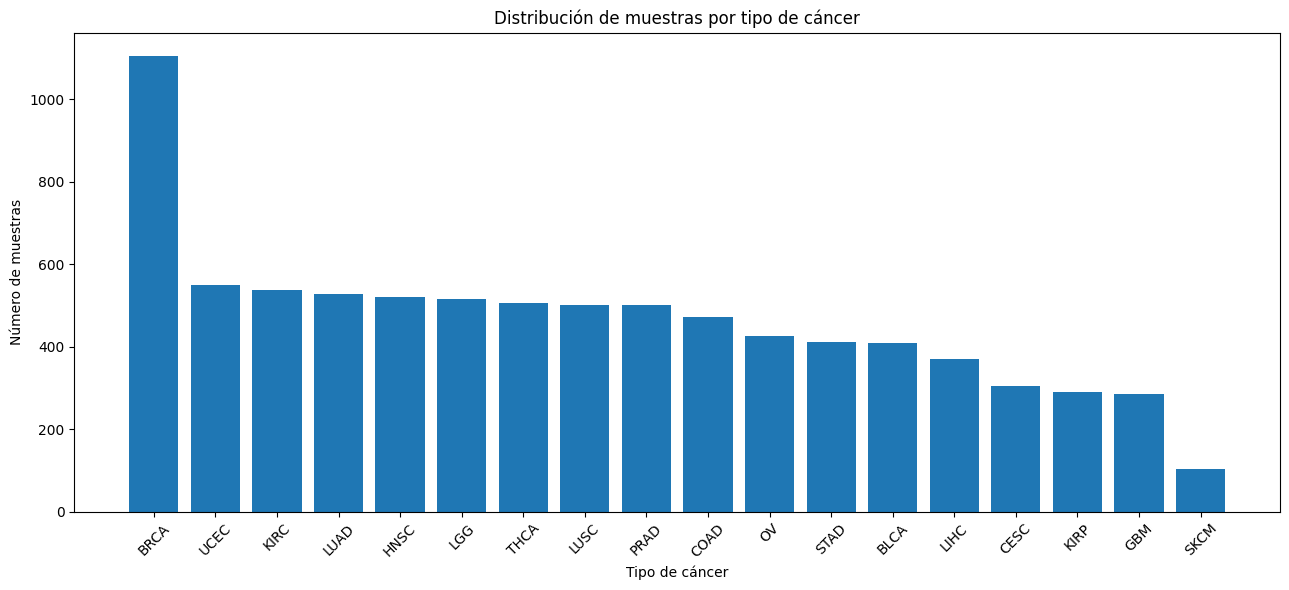

Gráfico guardado en: /Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/distribucion_clases.png


In [0]:
# Gráfico de distribución de clases

pdf_clases = eda_conteo_clases.toPandas()

plt.figure(figsize=(13, 6))
plt.bar(pdf_clases["cancer_type"], pdf_clases["n_muestras"])
plt.title("Distribución de muestras por tipo de cáncer")
plt.xlabel("Tipo de cáncer")
plt.ylabel("Número de muestras")
plt.xticks(rotation=45)
plt.tight_layout()

ruta_grafico = f"{REFINED_VISUALIZATIONS_PATH}/distribucion_clases.png"
plt.savefig(ruta_grafico, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico guardado en:", ruta_grafico)

4. Validación de tipos de muestra y alcance del dataset

In [0]:
# Validar tipos de muestra
eda_sample_type = spark.sql(f"""
    SELECT
        sample_type,
        COUNT(DISTINCT sample_id) AS n_muestras,
        COUNT(DISTINCT patient_id) AS n_pacientes
    FROM {TABLA_LONG}
    GROUP BY sample_type
    ORDER BY n_muestras DESC
""")

display(eda_sample_type)

guardar_refined(
    eda_sample_type,
    "refined_eda_tipos_muestra",
    "tipos_muestra"
)

sample_type,n_muestras,n_pacientes
Primary Tumor,8335,8283


Tabla creada: workspace.default.refined_eda_tipos_muestra


'/Volumes/workspace/default/tcga_cancer_ml/refined/eda_outputs/tipos_muestra'

In [0]:
# Validar clases oficiales

clases_obtenidas = set([r["cancer_type"] for r in df_samples.select("cancer_type").distinct().collect()])
clases_esperadas = set(CLASES_PRINCIPALES)

print("Número de clases esperadas:", len(clases_esperadas))
print("Número de clases obtenidas:", len(clases_obtenidas))
print("Clases faltantes:", clases_esperadas - clases_obtenidas)
print("Clases no esperadas:", clases_obtenidas - clases_esperadas)

Número de clases esperadas: 18
Número de clases obtenidas: 18
Clases faltantes: set()
Clases no esperadas: set()


5. Calidad de datos en la expresión génica

In [0]:
# Calidad de datos: nulos y ceros

eda_calidad_datos = spark.sql(f"""
    SELECT
        cancer_type,
        COUNT(*) AS n_registros,
        SUM(CASE WHEN log2_tpm IS NULL THEN 1 ELSE 0 END) AS n_log2_tpm_null,
        SUM(CASE WHEN tpm_unstranded IS NULL THEN 1 ELSE 0 END) AS n_tpm_null,
        SUM(CASE WHEN tpm_unstranded = 0 THEN 1 ELSE 0 END) AS n_tpm_cero,
        ROUND(100 * SUM(CASE WHEN tpm_unstranded = 0 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_tpm_cero
    FROM {TABLA_LONG}
    GROUP BY cancer_type
    ORDER BY pct_tpm_cero DESC
""")

display(eda_calidad_datos)

guardar_refined(
    eda_calidad_datos,
    "refined_eda_calidad_datos",
    "calidad_datos"
)

cancer_type,n_registros,n_log2_tpm_null,n_tpm_null,n_tpm_cero,pct_tpm_cero
LIHC,7405902,0,0,1259617,17.01
COAD,9601722,0,0,1531181,15.95
SKCM,2056086,0,0,314600,15.3
KIRP,5788980,0,0,850598,14.69
BLCA,8224344,0,0,1201066,14.6
THCA,10080810,0,0,1449224,14.38
UCEC,11038986,0,0,1583616,14.35
CESC,6068448,0,0,868308,14.31
HNSC,10380240,0,0,1438369,13.86
BRCA,22177782,0,0,3013154,13.59


Tabla creada: workspace.default.refined_eda_calidad_datos


'/Volumes/workspace/default/tcga_cancer_ml/refined/eda_outputs/calidad_datos'

In [0]:
# Genes detectados por muestra
# Un gen se considera detectado si TPM > 0

eda_genes_detectados_muestra = spark.sql(f"""
    WITH genes_por_muestra AS (
        SELECT
            sample_id,
            cancer_type,
            SUM(CASE WHEN tpm_unstranded > 0 THEN 1 ELSE 0 END) AS genes_detectados,
            COUNT(*) AS genes_totales
        FROM {TABLA_LONG}
        GROUP BY sample_id, cancer_type
    )
    SELECT
        cancer_type,
        COUNT(*) AS n_muestras,
        ROUND(AVG(genes_detectados), 2) AS media_genes_detectados,
        ROUND(STDDEV(genes_detectados), 2) AS sd_genes_detectados,
        MIN(genes_detectados) AS min_genes_detectados,
        MAX(genes_detectados) AS max_genes_detectados,
        ROUND(100 * AVG(genes_detectados / genes_totales), 2) AS pct_promedio_genes_detectados
    FROM genes_por_muestra
    GROUP BY cancer_type
    ORDER BY media_genes_detectados DESC
""")

display(eda_genes_detectados_muestra)

guardar_refined(
    eda_genes_detectados_muestra,
    "refined_eda_genes_detectados_muestra",
    "genes_detectados_muestra"
)

cancer_type,n_muestras,media_genes_detectados,sd_genes_detectados,min_genes_detectados,max_genes_detectados,pct_promedio_genes_detectados
GBM,285,23002.07,8214.9,16299,52740,88.35
LUSC,501,17821.92,2583.16,15733,36356,87.49
STAD,412,17821.56,520.09,16437,19285,89.28
LUAD,529,17655.11,2517.41,16020,35544,86.63
OV,426,17597.49,348.9,16126,18503,88.15
KIRC,537,17520.68,1532.58,15732,35668,87.13
LGG,516,17419.3,227.62,16403,18166,87.26
BRCA,1106,17327.87,1207.36,15754,34772,86.41
PRAD,501,17303.64,290.73,16246,18838,86.68
UCEC,549,17222.9,1591.67,15548,35596,85.64


Tabla creada: workspace.default.refined_eda_genes_detectados_muestra


'/Volumes/workspace/default/tcga_cancer_ml/refined/eda_outputs/genes_detectados_muestra'

6. Estadísticas de expresión génica

In [0]:
# Estadísticas globales de expresión por clase

eda_expresion_global = spark.sql(f"""
    SELECT
        cancer_type,
        COUNT(*) AS n_registros,
        ROUND(AVG(log2_tpm), 4) AS media_log2_tpm,
        ROUND(STDDEV(log2_tpm), 4) AS sd_log2_tpm,
        ROUND(MIN(log2_tpm), 4) AS min_log2_tpm,
        ROUND(percentile_approx(log2_tpm, 0.25), 4) AS q1_log2_tpm,
        ROUND(percentile_approx(log2_tpm, 0.50), 4) AS mediana_log2_tpm,
        ROUND(percentile_approx(log2_tpm, 0.75), 4) AS q3_log2_tpm,
        ROUND(MAX(log2_tpm), 4) AS max_log2_tpm
    FROM {TABLA_LONG}
    GROUP BY cancer_type
    ORDER BY cancer_type
""")

display(eda_expresion_global)

guardar_refined(
    eda_expresion_global,
    "refined_eda_expresion_global",
    "expresion_global"
)

cancer_type,n_registros,media_log2_tpm,sd_log2_tpm,min_log2_tpm,q1_log2_tpm,mediana_log2_tpm,q3_log2_tpm,max_log2_tpm
BLCA,8224344,2.7135,2.4391,0.0,0.2167,2.4953,4.5337,16.9432
BRCA,22177782,2.9241,2.475,0.0,0.3149,2.8828,4.8144,18.0636
CESC,6068448,2.7861,2.4765,0.0,0.2167,2.6236,4.6615,17.324
COAD,9601722,2.7731,2.4612,0.0,0.2327,2.5995,4.6339,16.784
GBM,7425864,2.7851,2.2825,0.0,0.458,2.7407,4.4715,16.0216
HNSC,10380240,2.7207,2.4526,0.0,0.2192,2.4919,4.55,16.5445
KIRC,10799442,2.7792,2.3895,0.0,0.2807,2.7008,4.5611,16.9897
KIRP,5788980,2.6392,2.372,0.0,0.2033,2.4256,4.4061,17.4248
LGG,10300392,2.9575,2.4253,0.0,0.3936,2.9858,4.8031,17.1992
LIHC,7405902,2.3125,2.3247,0.0,0.1021,1.8084,3.8946,17.4027


Tabla creada: workspace.default.refined_eda_expresion_global


'/Volumes/workspace/default/tcga_cancer_ml/refined/eda_outputs/expresion_global'

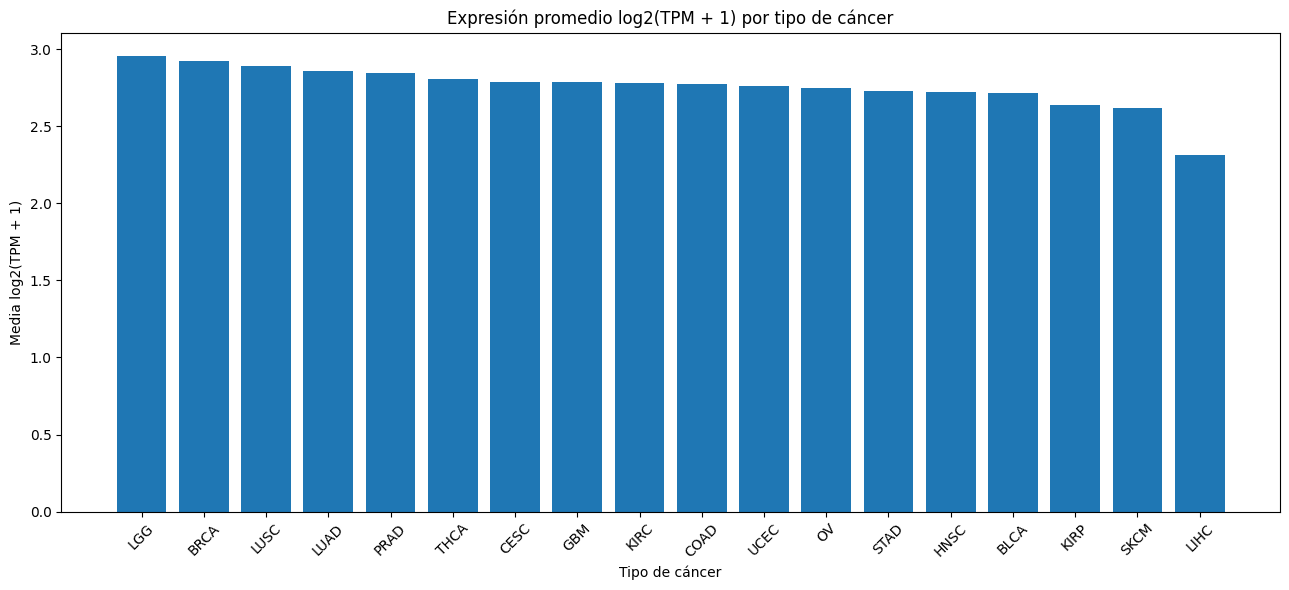

Gráfico guardado en: /Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/expresion_promedio_por_clase.png


In [0]:
# Gráfico de expresión promedio por clase

pdf_expr = eda_expresion_global.toPandas().sort_values("media_log2_tpm", ascending=False)

plt.figure(figsize=(13, 6))
plt.bar(pdf_expr["cancer_type"], pdf_expr["media_log2_tpm"])
plt.title("Expresión promedio log2(TPM + 1) por tipo de cáncer")
plt.xlabel("Tipo de cáncer")
plt.ylabel("Media log2(TPM + 1)")
plt.xticks(rotation=45)
plt.tight_layout()

ruta_grafico_expr = f"{REFINED_VISUALIZATIONS_PATH}/expresion_promedio_por_clase.png"
plt.savefig(ruta_grafico_expr, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico guardado en:", ruta_grafico_expr)

7. Genes más expresados por clase


In [0]:
# Top 10 genes más expresados por clase
eda_top_genes_por_clase = spark.sql(f"""
    WITH expresion_gen AS (
        SELECT
            cancer_type,
            gene_id_base,
            gene_name,
            AVG(log2_tpm) AS avg_log2_tpm
        FROM {TABLA_LONG}
        GROUP BY cancer_type, gene_id_base, gene_name
    ),
    ranking AS (
        SELECT
            *,
            ROW_NUMBER() OVER (
                PARTITION BY cancer_type
                ORDER BY avg_log2_tpm DESC
            ) AS rank_gen
        FROM expresion_gen
    )
    SELECT
        cancer_type,
        rank_gen,
        gene_id_base,
        gene_name,
        ROUND(avg_log2_tpm, 4) AS avg_log2_tpm
    FROM ranking
    WHERE rank_gen <= 10
    ORDER BY cancer_type, rank_gen
""")

display(eda_top_genes_por_clase)

guardar_refined(
    eda_top_genes_por_clase,
    "refined_eda_top_genes_por_clase",
    "top_genes_por_clase"
)

cancer_type,rank_gen,gene_id_base,gene_name,avg_log2_tpm
BLCA,1,ENSG00000198712,MT-CO2,14.7587
BLCA,2,ENSG00000198938,MT-CO3,14.5778
BLCA,3,ENSG00000198886,MT-ND4,14.3424
BLCA,4,ENSG00000198804,MT-CO1,14.2736
BLCA,5,ENSG00000198899,MT-ATP6,13.7906
BLCA,6,ENSG00000198840,MT-ND3,13.721
BLCA,7,ENSG00000198727,MT-CYB,13.6265
BLCA,8,ENSG00000198763,MT-ND2,13.5281
BLCA,9,ENSG00000198888,MT-ND1,13.1332
BLCA,10,ENSG00000034510,TMSB10,12.9818


Tabla creada: workspace.default.refined_eda_top_genes_por_clase


'/Volumes/workspace/default/tcga_cancer_ml/refined/eda_outputs/top_genes_por_clase'

8. Genes con mayor variabilidad entre clases

In [0]:
# Genes con mayor variabilidad entre tipos de cáncer

TOP_GENES_VARIABLES = 5000
eda_genes_mas_variables = spark.sql(f"""
    WITH media_por_clase AS (
        SELECT
            gene_id_base,
            gene_name,
            cancer_type,
            AVG(log2_tpm) AS media_clase
        FROM {TABLA_LONG}
        GROUP BY gene_id_base, gene_name, cancer_type
    ),
    variabilidad AS (
        SELECT
            gene_id_base,
            gene_name,
            AVG(media_clase) AS media_global,
            STDDEV(media_clase) AS sd_entre_clases,
            MAX(media_clase) - MIN(media_clase) AS rango_entre_clases
        FROM media_por_clase
        GROUP BY gene_id_base, gene_name
    )
    SELECT
        gene_id_base,
        gene_name,
        ROUND(media_global, 4) AS media_global,
        ROUND(sd_entre_clases, 4) AS sd_entre_clases,
        ROUND(rango_entre_clases, 4) AS rango_entre_clases
    FROM variabilidad
    ORDER BY sd_entre_clases DESC
    LIMIT {TOP_GENES_VARIABLES}
""")

display(eda_genes_mas_variables)

guardar_refined(
    eda_genes_mas_variables,
    "refined_eda_genes_mas_variables",
    "genes_mas_variables"
)

gene_id_base,gene_name,media_global,sd_entre_clases,rango_entre_clases
ENSG00000186081,KRT5,4.1985,4.105,12.7183
ENSG00000205420,KRT6A,3.5464,4.0173,13.119
ENSG00000186847,KRT14,3.4381,3.7118,13.2007
ENSG00000131095,GFAP,1.5914,3.708,12.0203
ENSG00000171345,KRT19,7.4214,3.6706,10.8336
ENSG00000128422,KRT17,5.4101,3.5483,11.54
ENSG00000186832,KRT16,3.3211,3.4745,11.6363
ENSG00000106541,AGR2,4.6437,3.4251,9.3702
ENSG00000165215,CLDN3,5.7522,3.3917,9.9525
ENSG00000184292,TACSTD2,6.8283,3.3235,9.9644


Tabla creada: workspace.default.refined_eda_genes_mas_variables


'/Volumes/workspace/default/tcga_cancer_ml/refined/eda_outputs/genes_mas_variables'

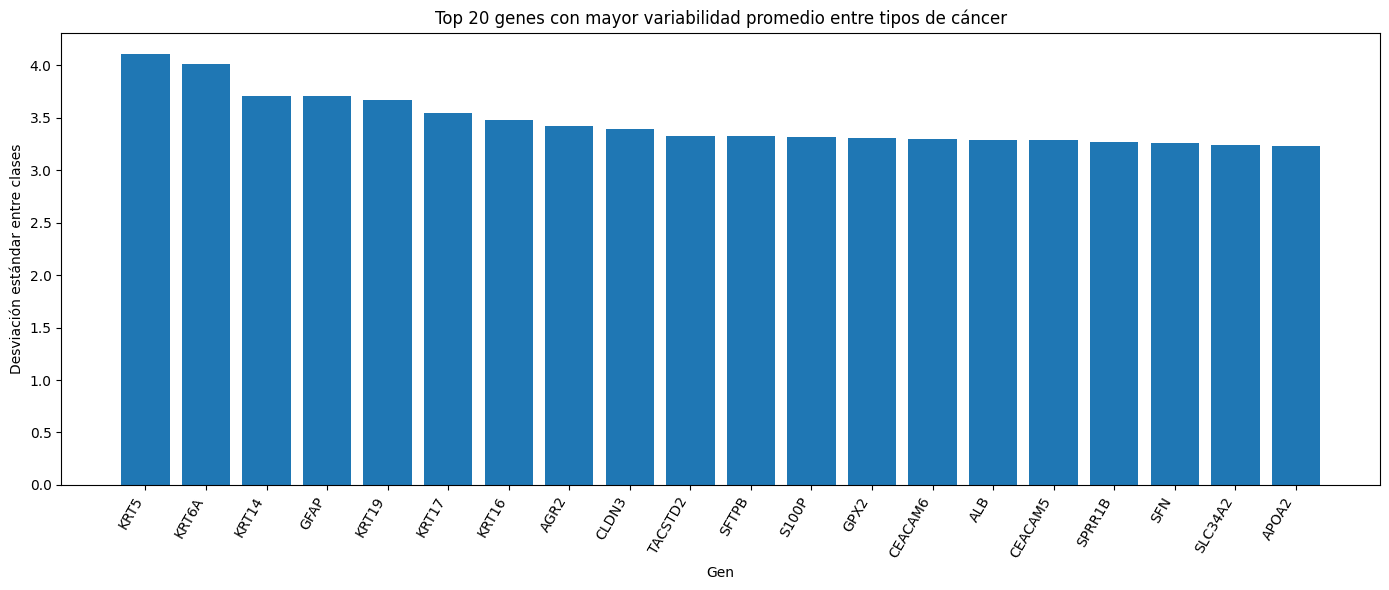

Gráfico guardado en: /Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/top20_genes_variables.png


In [0]:
# Gráfico de top 20 genes más variables entre clases

pdf_genes_var = eda_genes_mas_variables.limit(20).toPandas()

plt.figure(figsize=(14, 6))
plt.bar(pdf_genes_var["gene_name"], pdf_genes_var["sd_entre_clases"])
plt.title("Top 20 genes con mayor variabilidad promedio entre tipos de cáncer")
plt.xlabel("Gen")
plt.ylabel("Desviación estándar entre clases")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()

ruta_grafico_genes = f"{REFINED_VISUALIZATIONS_PATH}/top20_genes_variables.png"
plt.savefig(ruta_grafico_genes, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico guardado en:", ruta_grafico_genes)

9. Revisión de pacientes con más de una muestra

In [0]:
# Pacientes con más de una muestra

eda_muestras_por_paciente = spark.sql(f"""
    WITH muestras_paciente AS (
        SELECT
            patient_id,
            cancer_type,
            COUNT(DISTINCT sample_id) AS n_muestras
        FROM {TABLA_LONG}
        GROUP BY patient_id, cancer_type
    )
    SELECT
        cancer_type,
        COUNT(*) AS n_pacientes,
        SUM(CASE WHEN n_muestras > 1 THEN 1 ELSE 0 END) AS pacientes_con_mas_de_una_muestra,
        MAX(n_muestras) AS max_muestras_por_paciente
    FROM muestras_paciente
    GROUP BY cancer_type
    ORDER BY pacientes_con_mas_de_una_muestra DESC
""")

display(eda_muestras_por_paciente)

guardar_refined(
    eda_muestras_por_paciente,
    "refined_eda_muestras_por_paciente",
    "muestras_por_paciente"
)

cancer_type,n_pacientes,pacientes_con_mas_de_una_muestra,max_muestras_por_paciente
COAD,458,13,2
LUAD,517,12,2
BRCA,1095,11,2
UCEC,545,4,2
KIRC,533,4,2
PRAD,497,4,2
BLCA,406,3,2
GBM,284,1,2
LGG,516,0,1
LUSC,501,0,1


Tabla creada: workspace.default.refined_eda_muestras_por_paciente


'/Volumes/workspace/default/tcga_cancer_ml/refined/eda_outputs/muestras_por_paciente'

In [0]:
# Verificación final de tablas y archivos refined

print("Tablas refined_eda creadas:")
display(spark.sql("SHOW TABLES IN workspace.default LIKE 'refined_eda*'"))

print("Contenido físico en refined/eda_outputs:")
display(dbutils.fs.ls(REFINED_EDA_PATH))

print("Contenido físico en refined/visualizations:")
display(dbutils.fs.ls(REFINED_VISUALIZATIONS_PATH))

Tablas refined_eda creadas:


database,tableName,isTemporary
default,refined_eda_calidad_datos,false
default,refined_eda_conteo_clases,false
default,refined_eda_desbalance_clases,false
default,refined_eda_expresion_global,false
default,refined_eda_genes_detectados_muestra,false
default,refined_eda_genes_mas_variables,false
default,refined_eda_muestras_por_paciente,false
default,refined_eda_resumen_general,false
default,refined_eda_tipos_muestra,false
default,refined_eda_top_genes_por_clase,false


Contenido físico en refined/eda_outputs:


path,name,size,modificationTime
dbfs:/Volumes/workspace/default/tcga_cancer_ml/refined/eda_outputs/calidad_datos/,calidad_datos/,0,1777741091716
dbfs:/Volumes/workspace/default/tcga_cancer_ml/refined/eda_outputs/conteo_clases/,conteo_clases/,0,1777741091716
dbfs:/Volumes/workspace/default/tcga_cancer_ml/refined/eda_outputs/expresion_global/,expresion_global/,0,1777741091716
dbfs:/Volumes/workspace/default/tcga_cancer_ml/refined/eda_outputs/resumen_general/,resumen_general/,0,1777741091716
dbfs:/Volumes/workspace/default/tcga_cancer_ml/refined/eda_outputs/top_genes_por_clase/,top_genes_por_clase/,0,1777741091716


Contenido físico en refined/visualizations:


path,name,size,modificationTime
dbfs:/Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/comparacion_modelos_f1_macro.png,comparacion_modelos_f1_macro.png,220694,1777740529000
dbfs:/Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/curvas_precision_recall_ovr_mejor_modelo.png,curvas_precision_recall_ovr_mejor_modelo.png,145010,1777740556000
dbfs:/Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/curvas_roc_ovr_mejor_modelo.png,curvas_roc_ovr_mejor_modelo.png,157316,1777740556000
dbfs:/Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/distribucion_clases.png,distribucion_clases.png,155040,1777741021000
dbfs:/Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/expresion_promedio_por_clase.png,expresion_promedio_por_clase.png,155575,1777741062000
dbfs:/Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/matriz_confusion_mejor_modelo.png,matriz_confusion_mejor_modelo.png,225823,1777740549000
dbfs:/Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/top20_genes_variables.png,top20_genes_variables.png,224680,1777741084000
